#cmd-pip install numpy pandas scikit-learn openpyxl matplotlib seaborn plotly

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

import seaborn as sns
from sklearn.preprocessing import LabelEncoder , MinMaxScaler , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [2]:
bs=pd.read_csv('boston.csv')  #getting data from current directory
bs

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [3]:
bs.head(1)  #view first row

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.09,1,296,15.3,396.9,4.98,24.0


 machine learns from numeric data only 

1) **independent X** : all feature by using which we do prediction
2) **dependent Y** : feature that we are trying to predict


In [4]:
x=bs.drop('Price',axis=1)
x
y=bs.Price


In [9]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: Price, Length: 506, dtype: float64

In [5]:
x

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [11]:
x.dtypes  

# all columns of x shud be numeric because machine learns from numeric data

Unnamed: 0      int64
CRIM          float64
ZN            float64
INDUS         float64
CHAS            int64
NOX           float64
RM            float64
AGE           float64
DIS           float64
RAD             int64
TAX             int64
PTRATIO       float64
B             float64
LSTAT         float64
dtype: object

#splitting data into training and testing 2 parts
1) training data will be used to train ml model 
2) by using testing data we will evaluate how the model will perform when new data comes


In [7]:
xtrain , xtest , ytrain , ytest = train_test_split(x,y,train_size=0.75,random_state=42)

In [8]:
print('training_data: ', xtrain.shape)

print('testing data:' , xtest.shape)

print('training_data%' , round(xtrain.shape[0]/x.shape[0],2)) #training rows/total rows


training_data:  (379, 14)
testing data: (127, 14)
training_data% 0.75


In [9]:
xtest

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
173,173,0.09178,0.0,4.05,0,0.510,6.416,84.1,2.6463,5,296,16.6,395.50,9.04
274,274,0.05644,40.0,6.41,1,0.447,6.758,32.9,4.0776,4,254,17.6,396.90,3.53
491,491,0.10574,0.0,27.74,0,0.609,5.983,98.8,1.8681,4,711,20.1,390.11,18.07
72,72,0.09164,0.0,10.81,0,0.413,6.065,7.8,5.2873,4,305,19.2,390.91,5.52
452,452,5.09017,0.0,18.10,0,0.713,6.297,91.8,2.3682,24,666,20.2,385.09,17.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,418,73.53410,0.0,18.10,0,0.679,5.957,100.0,1.8026,24,666,20.2,16.45,20.62
117,117,0.15098,0.0,10.01,0,0.547,6.021,82.6,2.7474,6,432,17.8,394.51,10.30
42,42,0.14150,0.0,6.91,0,0.448,6.169,6.6,5.7209,3,233,17.9,383.37,5.81
322,322,0.35114,0.0,7.38,0,0.493,6.041,49.9,4.7211,5,287,19.6,396.90,7.70


In [10]:
ytest

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
418     8.8
117    19.2
42     25.3
322    20.4
347    23.1
Name: Price, Length: 127, dtype: float64

#  creating linear regression model 

 #it will help us to predict property prices

 #equation : Mx + C for simple linear regression 

 #**M1x1 + M2x2 + .... M14x14 + C**

 #in linear regression we got 2 values M(coeff) and C(intercept)

 #here x is a data point available in x data

 #number of M valuesw are equal to number of col in independent data

In [11]:
LR=LinearRegression()

In [12]:
LR.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[-0. ,-0.13, 0.03,...,-0.92, 0.01,-0.52]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['Unnamed: 0','CRIM','ZN',...,'PTRATIO','B','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [13]:
LR.coef_

array([-3.81838194e-03, -1.28913766e-01,  3.21436516e-02,  5.24989786e-02,
        2.74680799e+00, -1.59967525e+01,  4.42157283e+00, -1.40118980e-02,
       -1.43260913e+00,  2.89952243e-01, -9.10281778e-03, -9.19028939e-01,
        1.32758154e-02, -5.21843544e-01])

In [14]:
LR.intercept_

np.float64(29.999559608646386)

#M1x1 + M2x2  + ... M14x14 + C

In [15]:
pred=LR.predict(xtest)
pred

array([28.8132882 , 35.84280936, 14.18357915, 25.8537564 , 18.75779032,
       23.64837829, 16.92827786, 14.51557111, 22.81566115, 19.49149418,
       24.47295791, 19.13544761, -7.20365053, 22.32821029, 18.55483909,
       26.23084019, 20.52140367,  5.62563476, 40.66618599, 17.49542852,
       27.12305967, 29.86880245, 11.49153413, 22.83402768, 17.87338341,
       15.48399718, 23.52933579, 14.09499248, 21.91614534, 18.14941864,
       22.1596285 , 24.76888415, 25.9212345 , 18.19246131, 16.43816408,
       17.27951364, 31.78447326, 19.55509593, 23.53587651, 25.4183317 ,
       12.79298865, 31.6228272 , 42.79297105, 17.89770487, 27.39596192,
       17.14637792, 14.24961989, 26.7135042 , 20.16191241, 30.59601042,
       21.85614811, 34.0311554 , 16.31872396, 26.61788915, 39.36915276,
       22.73152223, 18.84618888, 32.57535435, 25.32377961, 12.56768248,
       23.34980607, 31.27256961, 31.78756182, 16.62266565, 19.99237008,
       16.06623792, 20.58932571, 26.50508174, 31.43892874, 11.24

In [16]:
LR.predict(xtest) .size

127

In [17]:
ytest

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
418     8.8
117    19.2
42     25.3
322    20.4
347    23.1
Name: Price, Length: 127, dtype: float64

In [18]:
EVL=pd.DataFrame({'Actual':ytest , 'Predictions': pred})

# Evaluation [performance testing]
 1) RMSE [ROOT MEAN SQUARED ERROR]
 2) MSE [mean squared error]   (Y-Y^)**2
 3) MAE [mean absolute error]
 4) R2 [R squared Value]
 5) Adj R2 [adjusted R squared value]

NOTE : Y is the actuial price and Y^ is the prediction by linear regression 



In [ ]:
#evl all is for manual calc only learning 
EVL['MSE'] = (EVL['Actual'] - EVL ['Predictions'])**2

In [46]:
EVL.head(2)

,Actual,Predictions,MSE
173,23.6,28.813288,27.178374
274,32.4,35.842809,11.852936


In [47]:
EVL['MSE'].mean()

np.float64(22.359316311907268)

In [ ]:
EVL['MSE'].mean()**0.5  #root mean squared error

np.float64(4.728563874149028)

In [ ]:
EVL['MAE'] = abs(EVL['Actual'] - EVL ['Predictions'])  #mean absolute error

In [51]:
EVL

,Actual,Predictions,MSE,MAE
173,23.6,28.813288,27.178374,5.213288
274,32.4,35.842809,11.852936,3.442809
491,13.6,14.183579,0.340565,0.583579
72,22.8,25.853756,9.325428,3.053756
452,16.1,18.757790,7.063849,2.657790
...,...,...,...,...
418,8.8,3.158019,31.831949,5.641981
117,19.2,24.148628,24.488920,4.948628
42,25.3,26.361480,1.126741,1.061480
322,20.4,22.549115,4.618697,2.149115


In [52]:
EVL['MAE'].mean()

np.float64(3.081381295403091)

In [54]:
EVL['R2']=EVL['Actual'].mean()

In [56]:
EVL.columns

Index(['Actual', 'Predictions', 'MSE', 'MAE', 'R2'], dtype='str')

In [ ]:
y_hat=((EVL['Predictions']-EVL['Actual'])**2).mean()  #linear ka error diff is less

In [ ]:
y_bar=((EVL['R2']-EVL['Actual'])**2).mean()  #normal error diff is more

In [59]:
y_bar

np.float64(70.0271436542873)

In [60]:
y_hat

np.float64(22.359316311907268)

In [ ]:
1-(y_hat/y_bar)    #error reduce krta , avg model se linear model 68 perc acha kaam kar rha 

np.float64(0.6807050074426625)

In [ ]:
# R square gives us a score that how much %error we are able to reduce as compared with base model

In [19]:
R2=r2_score(ytest,pred)

In [20]:
MSE=mean_squared_error(ytest,pred)

In [21]:
RMSE=mean_squared_error(ytest,pred)**0.5

In [22]:
MAE=mean_absolute_error(ytest,pred)

In [23]:
print('performance matrix/testing: \n'.center(60))
print(round(MSE,2))
print(RMSE)
print(MAE)
print(R2)


               performance matrix/testing: 
                
22.36
4.728563874149028
3.081381295403091
0.6807050074426624


In [24]:
x

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [25]:
x.drop('Unnamed: 0',axis=1,inplace=True)

In [26]:
x

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [27]:
bs.corr().tail(1)

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
Price,-0.226604,-0.388305,0.360445,-0.483725,0.17526,-0.427321,0.69536,-0.376955,0.249929,-0.381626,-0.468536,-0.507787,0.333461,-0.737663,1.0


In [45]:
bs.drop('Unnamed: 0',axis=1,inplace=True)

KeyError: "['Unnamed: 0'] not found in axis"

In [46]:
bs.corr().tail(1)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
Price,-0.388305,0.360445,-0.483725,0.17526,-0.427321,0.69536,-0.376955,0.249929,-0.381626,-0.468536,-0.507787,0.333461,-0.737663,1.0


In [50]:
bs

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [47]:
price_corr=list(enumerate(bs.corr().tail(1).values[0]))
price_corr


[(0, np.float64(-0.38830460858681154)),
 (1, np.float64(0.3604453424505433)),
 (2, np.float64(-0.48372516002837274)),
 (3, np.float64(0.17526017719029868)),
 (4, np.float64(-0.42732077237328203)),
 (5, np.float64(0.6953599470715401)),
 (6, np.float64(-0.3769545650045961)),
 (7, np.float64(0.249928734085904)),
 (8, np.float64(-0.38162623063977735)),
 (9, np.float64(-0.4685359335677667)),
 (10, np.float64(-0.5077866855375623)),
 (11, np.float64(0.3334608196570662)),
 (12, np.float64(-0.7376627261740145)),
 (13, np.float64(1.0))]

In [51]:
x_sort=sorted(price_corr , key=lambda x: abs(x[1]) , reverse=True)[1:]
x_sort

[(12, np.float64(-0.7376627261740145)),
 (5, np.float64(0.6953599470715401)),
 (10, np.float64(-0.5077866855375623)),
 (2, np.float64(-0.48372516002837274)),
 (9, np.float64(-0.4685359335677667)),
 (4, np.float64(-0.42732077237328203)),
 (0, np.float64(-0.38830460858681154)),
 (8, np.float64(-0.38162623063977735)),
 (6, np.float64(-0.3769545650045961)),
 (1, np.float64(0.3604453424505433)),
 (11, np.float64(0.3334608196570662)),
 (7, np.float64(0.249928734085904)),
 (3, np.float64(0.17526017719029868))]

In [52]:
x_indexes =[i[0] for i in x_sort]
x_indexes

[12, 5, 10, 2, 9, 4, 0, 8, 6, 1, 11, 7, 3]

In [53]:
AdjR2s=[]
R2s=[]
x=x.iloc[:,x_indexes]
for i in range(len(x_indexes)):
    x_select=x.iloc[: , 0: i+1]
    xtrain,xtest,ytrain,ytest = train_test_split(x_select , y , test_size=0.25 , random_state=42)
    LR=LinearRegression()
    LR.fit(xtrain,ytrain)
    R2s.append(LR.score(xtest,ytest))
    R2=LR.score(xtest,ytest)
    n=xtest.shape[0]
    k=xtest.shape[1]
    AdjR2=(1-R2)*(n-1) / (n-k-1)
    AdjR2s.append(AdjR2)


Text(0, 0.5, 'AdjR2')

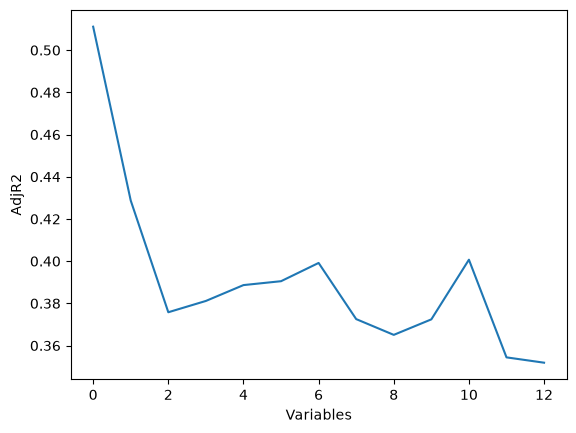

In [54]:
plt.plot(range(x.shape[1]),AdjR2s)
plt.xlabel('Variables')
plt.ylabel('AdjR2')

**REGULARIZATION**: Reducing difference between performance of training and testing


    #techniques :   L1[Ridge],
                    L2[Lasso],
                    EN[ElasticNet]



**OPTIMIZATION** : increasing accuracy of training and testing 


    #techniques :   GD[Gradient Descent],
                    SGD[Stochastic Gradient Descent],
                    MBGD[Mini Batch Gradient Descent]

In [56]:
L1=Ridge()
L2=Lasso()
EN=ElasticNet()

In [57]:
L1.fit(xtrain,ytrain)
L2.fit(xtrain,ytrain)
EN.fit(xtrain,ytrain)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [60]:
print(f'Ridge : Testing Score : {L1.score(xtest,ytest)} , Training score : {L1.score(xtrain,ytrain)}')
print(f'Lasso : Testing Score : {L2.score(xtest,ytest)} , Training score : {L2.score(xtrain,ytrain)}')
print(f'ElasticNet : Testing Score : {EN.score(xtest,ytest)} , Training score : {EN.score(xtrain,ytrain)}')

Ridge : Testing Score : 0.678974832784608 , Training score : 0.7461161787884156
Lasso : Testing Score : 0.6517111044875472 , Training score : 0.6948058568528785
ElasticNet : Testing Score : 0.655953698630833 , Training score : 0.6910898835689636


<Axes: xlabel='Actual', ylabel='Predictions'>

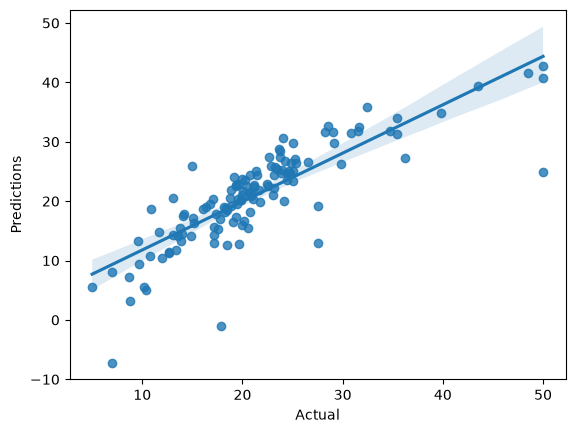

In [61]:
sns.regplot(x=EVL['Actual'],y=EVL['Predictions'])